In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("arjunbasandrai/25-indian-bird-species-with-226k-images")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 9.33G/9.33G [03:59<00:00, 41.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4
Contents of base_path (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions):
['4']
Contents of path (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4):
['training_set', 'training_data']


In [ ]:
print(f"Contents of the 'training_set' directory: {os.listdir(os.path.join(path, 'training_set'))}")
print(f"Contents of the 'training_data' directory: {os.listdir(os.path.join(path, 'training_data'))}")

Contents of the 'training_set' directory: ['training_set']
Contents of the 'training_data' directory: ['train', 'test', 'val']



--- Sample Images from training_set (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set) ---
Found 22620 images in /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set. Displaying 6 samples:


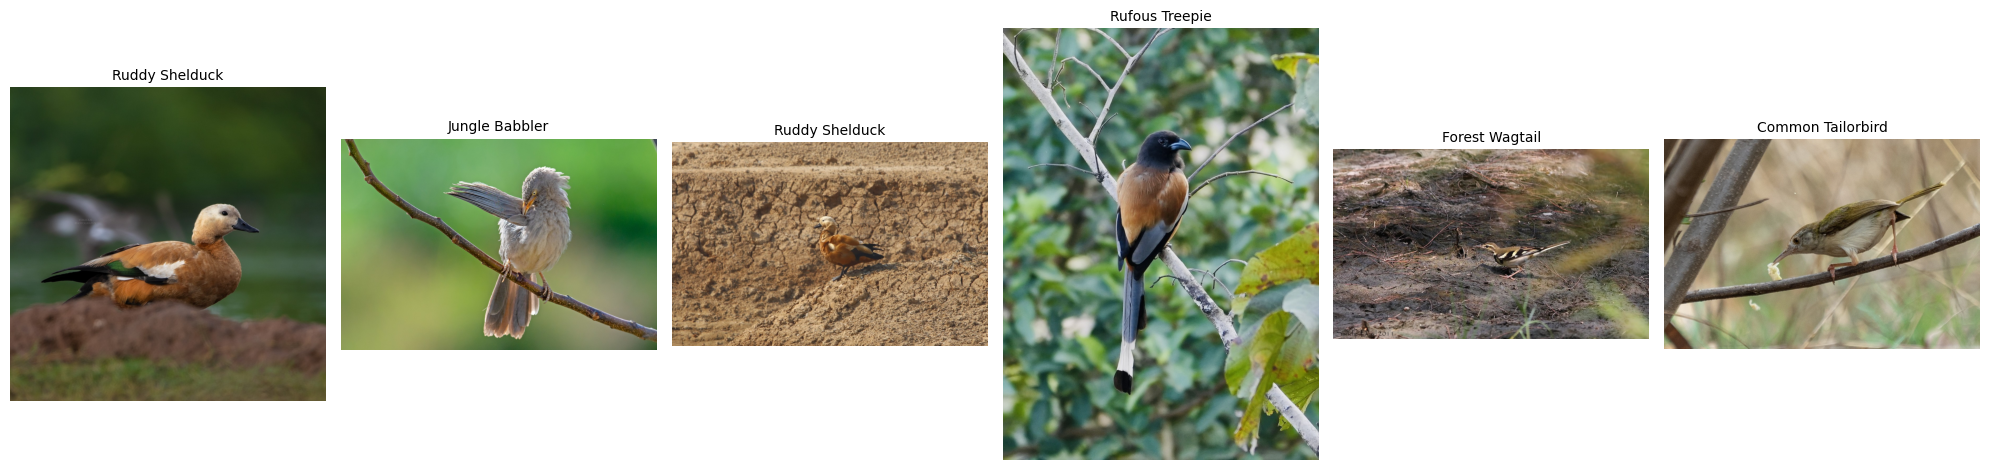


--- Sample Images from training_data (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_data) ---
No images found in /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_data.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Extract species name from the directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to use the actual dataset folders found in cell IXEO7kTkTmB8
training_set_path = os.path.join(path, 'training_set')
print(f"\n--- Sample Images from training_set ({training_set_path}) ---")
display_sample_images(training_set_path)

training_data_path = os.path.join(path, 'training_data')
print(f"\n--- Sample Images from training_data ({training_data_path}) ---")
display_sample_images(training_data_path)


In [ ]:
import os

# Define the actual path containing the bird species folders
# Based on previous results, it is located in training_set/training_set
input_folder = os.path.join(path, 'training_set', 'training_set')
output_folder = '/content/bird_dataset_split'

if not os.path.exists(input_folder):
    # Fallback if the directory structure is not nested
    input_folder = os.path.join(path, 'training_set')

print(f"Preparing to split data from: {input_folder}")

Preparing to split data from: /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set/training_set


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Split the dataset: train=0.8, test=0.2
# seed=42 to ensure reproducibility
# We are splitting into train and val (using val as the test set as requested)
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Data split successfully into folder: {output_folder}")

Copying files: 22620 files [00:44, 505.29 files/s]

Data split successfully into folder: /content/bird_dataset_split


In [ ]:
# Check the directory structure after splitting
for root, dirs, files in os.walk(output_folder):
    level = root.replace(output_folder, '').count(os.sep)
    indent = ' ' * 4 * (level)
    if level <= 2: # Only print up to species level to avoid long output
        print(f"{indent}{os.path.basename(root)}/")

bird_dataset_split/
    train/
        Coppersmith Barbet/
        Rufous Treepie/
        Sarus Crane/
        White-Breasted Waterhen/
        Northern Lapwing/
        Indian Pitta/
        House Crow/
        Forest Wagtail/
        Common Rosefinch/
        Common Tailorbird/
        Red-Wattled Lapwing/
        Ruddy Shelduck/
        Indian Grey Hornbill/
        Asian Green Bee-Eater/
        Brown-Headed Barbet/
        White Wagtail/
        Common Myna/
        Gray Wagtail/
        Jungle Babbler/
        Cattle Egret/
        Indian Peacock/
        White-Breasted Kingfisher/
        Common Kingfisher/
        Hoopoe/
        Indian Roller/
    val/
        Coppersmith Barbet/
        Rufous Treepie/
        Sarus Crane/
        White-Breasted Waterhen/
        Northern Lapwing/
        Indian Pitta/
        House Crow/
        Forest Wagtail/
        Common Rosefinch/
        Common Tailorbird/
        Red-Wattled Lapwing/
        Ruddy Shelduck/
        Indian Grey Hornb

In [ ]:
import os

def count_files(directory):
    return sum([len(files) for r, d, files in os.walk(directory)])

train_count = count_files(os.path.join(output_folder, 'train'))
test_count = count_files(os.path.join(output_folder, 'val'))
total = train_count + test_count

print(f"New dataset statistics:")
print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%)")
print(f"- Test Set (val): {test_count} images ({test_count/total*100:.1f}%)")
print(f"- Total: {total} images")

New dataset statistics:
- Train Set: 18090 images (80.0%)
- Test Set (val): 4530 images (20.0%)
- Total: 22620 images


In [ ]:
import torch

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# Data augmentation and normalization
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(output_folder, 'train'), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(output_folder, 'val'), data_transforms['val'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# Initialize ResNet18
model = models.resnet18(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
num_epochs = 10

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')

    for phase in ['train', 'val']:
        if phase == 'train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10
train Loss: 1.2594 Acc: 0.6403
val Loss: 0.7637 Acc: 0.7843
Epoch 2/10
train Loss: 0.9188 Acc: 0.7379
val Loss: 0.5964 Acc: 0.8313
Epoch 3/10
train Loss: 0.8143 Acc: 0.7635
val Loss: 0.4689 Acc: 0.8711
Epoch 4/10
train Loss: 0.7262 Acc: 0.7891
val Loss: 0.3457 Acc: 0.9020
Epoch 5/10
train Loss: 0.6996 Acc: 0.7977
val Loss: 0.3399 Acc: 0.9024
Epoch 6/10
train Loss: 0.6694 Acc: 0.8071
val Loss: 0.3001 Acc: 0.9161
Epoch 7/10
train Loss: 0.6304 Acc: 0.8176
val Loss: 0.2350 Acc: 0.9305
Epoch 8/10
train Loss: 0.6073 Acc: 0.8203
val Loss: 0.2666 Acc: 0.9249
Epoch 9/10
train Loss: 0.5833 Acc: 0.8313
val Loss: 0.2272 Acc: 0.9338
Epoch 10/10
train Loss: 0.5773 Acc: 0.8321
val Loss: 0.2343 Acc: 0.9329


In [ ]:
print("Training Summary:")
print(f"Final Training Accuracy: {history['train_acc'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history['val_acc'][-1]*100:.2f}%")
print(f"Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.4f}")

Training Summary:
Final Training Accuracy: 83.21%
Final Validation Accuracy: 93.29%
Final Training Loss: 0.5773
Final Validation Loss: 0.2343


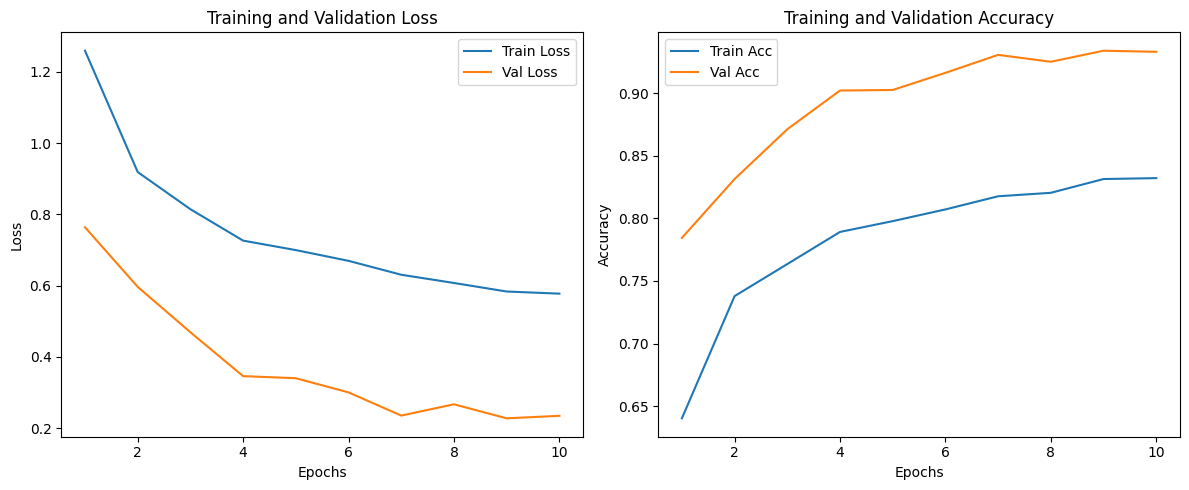

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc')
plt.plot(epochs_range, history['val_acc'], label='Val Acc')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()